In [12]:
import torch 
from matplotlib import pyplot as plt
import numpy as np
from hnet.synth import generate
from hnet.synth import utils 
from hnet.models.HyperNet import HyperNet
from hnet.models.MLP import MLP
from hnet.train.hnet import EnergyDistanceLoss
from hnet.models.BSpline import BSpline
import seaborn as sbn 
from sklearn.metrics import r2_score

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


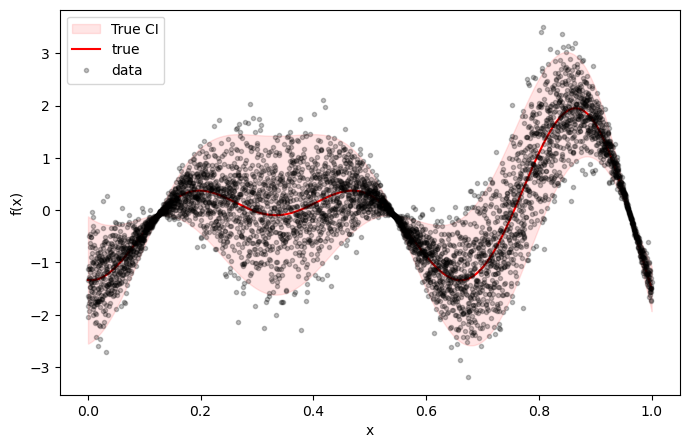

In [2]:
x,y,y_true,true_lcb,true_ucb = generate.simple1d(N=5000, scale=3)

# unit norm x 
x = (x - x.min(axis=0).values) / (x.max(axis=0).values - x.min(axis=0).values)

y_mu = y.mean(axis=0)
y_std = y.std(axis=0)
y = (y - y_mu) / y_std
y_true = (y_true - y_mu) / y_std 
true_lcb = (true_lcb - y_mu) / y_std 
true_ucb = (true_ucb - y_mu) / y_std 

assert x.min() >= 0.0 and x.max() <= 1.0, "Input must be in [0, 1] range"

utils.plot1d(x,y,y_true,true_lcb,true_ucb)

In [41]:
# NOTE: using many stochastic channels results in a wider range of diverse samples (at initiailization at least) 
# e.g., if we are only using 2 stochastic channels, the true function rarely appears in the function space 
# if using 100 stochastic channels, the true function appears in the function space almost always. 

gamma = 0.

mlp = MLP(in_channels       = 1, 
              out_channels      = 1, 
              hidden_channels   = 64, 
              layers            = 2, 
              nonlin            = 'elu', 
              norm              = 'none')

init_dict = mlp.get_init_dict(init='infer')

spline = BSpline(in_dim=1, out_dim=1, n_knots=32, degree=3)
hnet = HyperNet(mlp, stochastic_channels=64, width=256, dropout=0., norm='none', bias=False, affine=False,
               init_dict=init_dict, 
               pz='bernoulli', 
               learn_pz=True, 
               nvp_kwargs={
                           'hidden_dim':64, 
                           'num_layers':8, 
                           'nonlin':'elu', 
                           'mask_type':'alternating', 
                           })

print('# spline parameters: ', sum([p.numel() for p in spline.parameters()]))
print('# mlp parameters: ', sum([p.numel() for p in mlp.parameters()]))
print('# hnet parameters: ', sum([p.numel() for p in hnet.parameters()]))
print('# RealNVP parameters: ', sum([p.numel() for p in hnet.normalizing_flow.parameters()]))

# freeze normalizing flow
for param in hnet.normalizing_flow.parameters():
   param.requires_grad = False

optim = torch.optim.AdamW(hnet.parameters(), lr=1e-3, weight_decay=0)
crit = EnergyDistanceLoss()

batch_size = 500 

for i in range(1000):

   batch_idx = torch.randint(0, len(x), (batch_size,))
   x_batch = x[batch_idx]
   y_batch = y[batch_idx]
   
   optim.zero_grad()

   yhat = hnet(x_batch.unsqueeze(1), samples=100)
   edl = crit(yhat, y_batch.unsqueeze(1))

   div_loss = hnet.diversity_loss() 
   loss = edl + gamma*div_loss
   loss.backward()

   optim.step()  


   r2 = r2_score(y_batch.detach().cpu().numpy(), yhat.detach().cpu().numpy().mean(0))
   print(f'iter: {i}, loss {loss.item():.4f}, edl {edl.item():.4f}, div_loss {div_loss.item():.4f}, r2: {r2:.2f}', end='\r')


# spline parameters:  28
# mlp parameters:  8513
# hnet parameters:  2469441
# RealNVP parameters:  199680


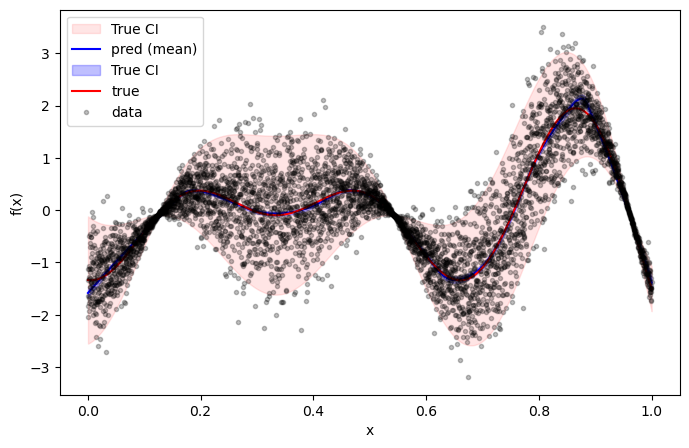

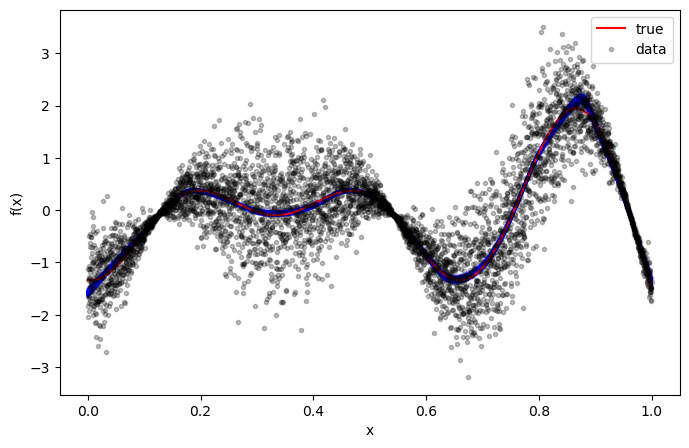

In [45]:
hnet.eval() 
yhat = hnet(x.unsqueeze(1), samples=500)

utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2=x, yhat=yhat, plot_ci=True)
utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2=x, yhat=yhat, plot_ci=False)



In [43]:

# unfreeze normalizing flow
for param in hnet.normalizing_flow.parameters():
    param.requires_grad = True 

# freeze all other parameters (f_phi)
for param in hnet.f_phi.parameters():
    param.requires_grad = False

optim = torch.optim.AdamW(hnet.normalizing_flow.parameters(), lr=1e-4, weight_decay=1e-6)
crit = torch.nn.MSELoss()


hnet.train()
for i in range(1000):
    optim.zero_grad()

    batch_idx = torch.randint(0, len(x), (batch_size,))
    x_batch = x[batch_idx]
    y_batch = y_true[batch_idx]  # NOTE: USING TRUE : Q: Does the true hypothesis exist in the function space? 

    yhat = hnet(x_batch.unsqueeze(1), samples=100)
    loss = crit(yhat, y_batch.unsqueeze(1))
    loss.backward()

    torch.nn.utils.clip_grad_norm_(hnet.parameters(), 1)

    optim.step()

    print(f'Epoch {i}, loss: {loss.item()}', end='\r')




/Users/evansna/miniforge3/envs/hnet/lib/python3.12/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([500, 1])) that is different to the input size (torch.Size([100, 500, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


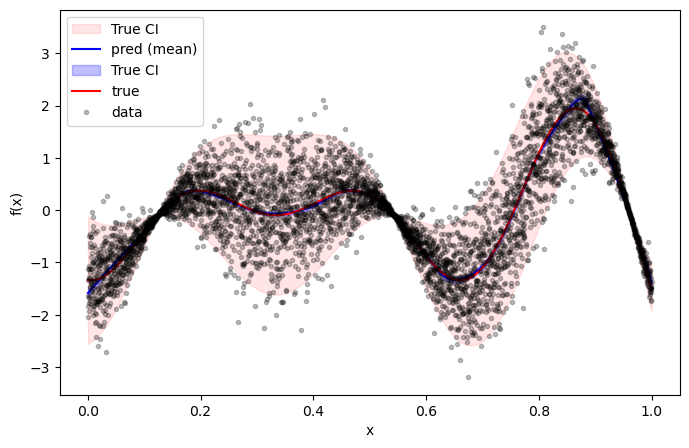

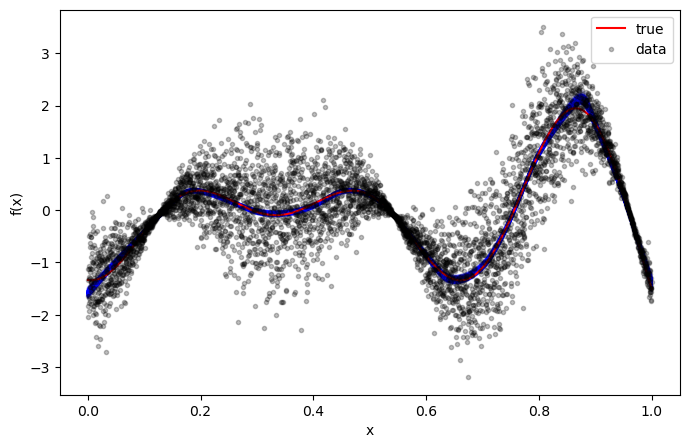

In [44]:
hnet.eval() 
yhat = hnet(x.unsqueeze(1), samples=250)

utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2=x, yhat=yhat, plot_ci=True)
utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2=x, yhat=yhat, plot_ci=False)



/var/folders/p8/qlbkccs94s9gh51v_kczck3ws2ydf9/T/ipykernel_54805/480941130.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


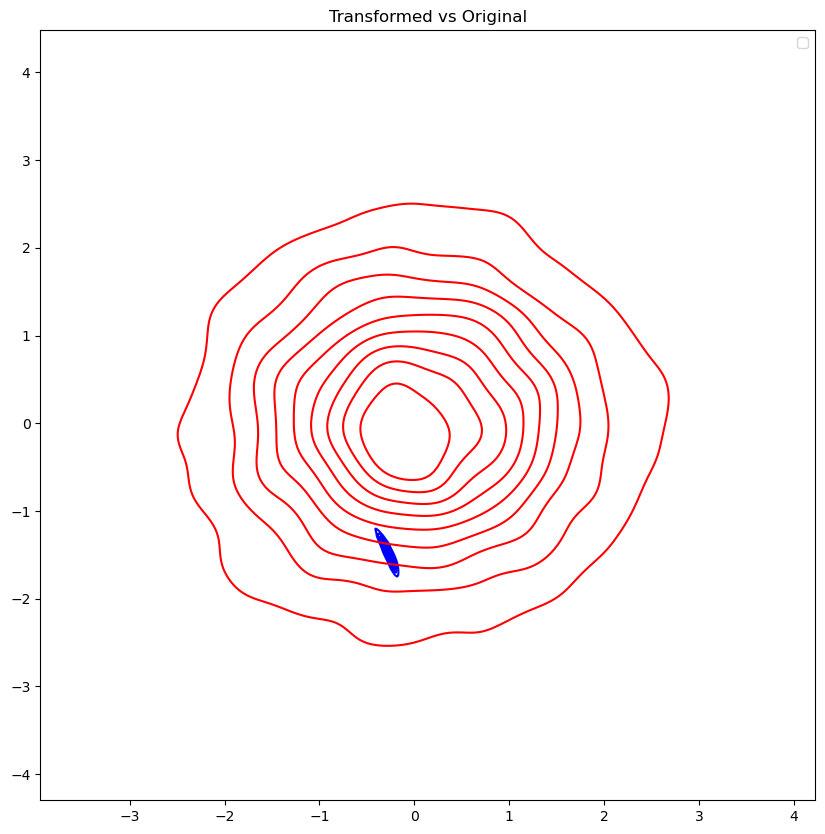

In [23]:
zn = torch.randn(5000, 2) 

zz = hnet.normalizing_flow(zn)


f,axes = plt.subplots(1,1, figsize=(10,10))

# contour plot of the two distributions
sbn.kdeplot(x=zz[:,0].detach().cpu().numpy(), y=zz[:,1].detach().cpu().numpy(), color='blue', label='Transformed')
sbn.kdeplot(x=zn[:,0].detach().cpu().numpy(), y=zn[:,1].detach().cpu().numpy(), color='red', label='Original')

plt.legend()
plt.title('Transformed vs Original')

plt.show()

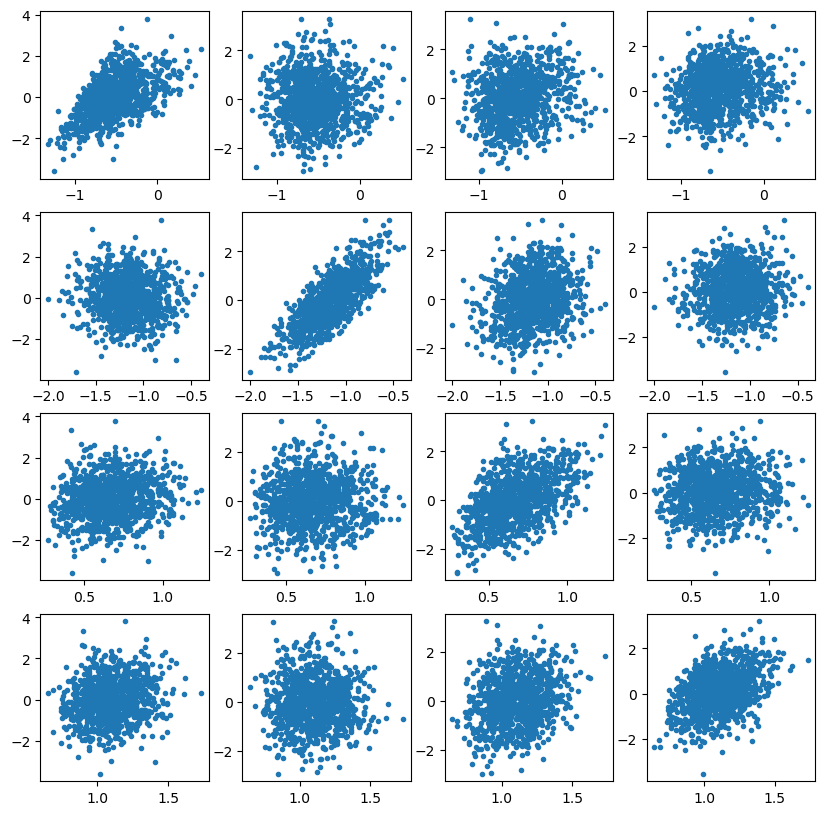

In [25]:


zn = torch.randn(1000, 20) 

zz = hnet.normalizing_flow(zn)

f,axes = plt.subplots(4,4, figsize=(10,10))

for i in range(4):
    for j in range(4):
        axes[i,j].plot(zz[:,i].detach().cpu().numpy(), zn[:,j].detach().cpu().numpy(), '.')

plt.show()